# Digital twin workshop

## Case study: Satellite Antenna System Digital Twin

<div class="alert alert-block alert-info"> <b>NOTE</b> Importing necessary libraries is crucial for the successful implementation of the digital twin. </div>

In [17]:
import os
import sys
sys.path.insert(0, os.path.realpath('../'))
import robot_package as rb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sym
import scipy as sp
import pyvista as pv
from tqdm import tqdm
import dill
import copy

## Antena parameter definition

### Create a list with class instances using create_links function
It is also possible to create each link seperately

In [4]:
dh_params = np.array([[0,0,0,0],
                     [0, np.pi/2, 0, 0],
                     [0, np.pi/2, 0, np.pi/2],
                     [840,0,0,0],
                     [204,np.pi/2,0,0],
                     [500,0,0,0]])

names = ['Rz_base', 'Rx_base', 'Ry_base', 'J1', 'J2', 'Dish']
types = ['fixed', 'revolute', 'revolute', 'revolute', 'revolute', 'revolute']

link_mass = np.array([0,0,0,60.1,37.76, 25.46])
com = np.array([[0,0,0],
                [0,0,0],
                [0,0,0],
                [-391,-50,-6],
                [-102,-29,29],
                [66,0,-16]])
I_0 = np.zeros(6)
I_1 = I = np.array([
    0.89111513,   # I_xx
    6.27826729,   # I_yy
    5.84993511,   # I_zz
   -0.00897292,   # I_xy
    0.00363926,   # I_yz
   -0.02012938    # I_xz
])

I_2 = np.array([
    0.49192216,   # I_xx
    0.71937076,   # I_yy
    0.53085469,   # I_zz
    0.01013016,   # I_xy
    0.00167016,   # I_yz
    0.04069648    # I_xz
])

I_3 = np.array([
    2.43480772,   # I_xx
    2.28476393,   # I_yy
    1.90360426,   # I_zz
    0.00011998,   # I_xy
   -0.00011349,   # I_yz
   -0.00634343    # I_xz
])
I_list= np.array([I_0, I_0, I_0, I_1, I_2, I_3])

stl_dir  = r'Data/Antena/Meshes/'

stl_paths = [None, None, None, stl_dir + 'pedestal.stl', stl_dir + 'J1.stl', stl_dir + 'J2.stl']

### Create a list with class instances using create_links function
It is also possible to create each link seperately

In [5]:
links = rb.create_links(names = names, 
                        dh_params = dh_params, 
                        types = types, 
                        stl_paths = stl_paths, 
                        mass=link_mass, 
                        CM = com,
                        inertia_matrix = I_list) 


### Use the list to create the robot class instance

In [8]:
Antena = rb.Robot(links, name='Antena',)

Computing link frames


100%|██████████| 6/6 [00:00<00:00, 51.45it/s]


In [9]:
Antena.plot()

c:\Users\matic\Desktop\DigitalTwin_Workshop\myvenv\Lib\site-packages\pyvista\core\utilities\misc.py:289: PyVistaDeprecationWarning: 
myvenv/Lib/site-packages/pyvista/core/utilities/misc.py:289: Arguments 'position', 'focal_point', 'color' must be passed as keyword arguments to function 'Light.__init__'.
From version 0.50, passing these as positional arguments will result in a TypeError.
  obj = super().__call__(*args, **kwargs)  # type: ignore[misc]


# try mooving the antena to explore the degrees of freedom

<div class="alert alert-block alert-info"> <b>NOTE</b>  The angles are in degrees [°]. </div>

In [13]:
q_1 = 0 # First degree of freedom [°]
q_2 = 0 # Second degree of freedom [°]
q_3 = 0 # Third degree of freedom [°]
q_4 = 0 # Fourth degree of freedom [°]
q_5 = 30 # Fifth degree of freedom [°]
Antena.update(q = np.array([q_1, q_2, q_3, q_4, q_5]))

In [15]:
K = np.array([12e3,12e3, 12e3, 1e3, 1e3])*4
C = np.ones(5) * 1

K = np.array([ 117258.20836947,  335680.56447426,  333024.67765765,
       2292564.16034057,  621432.32026823])

In [16]:
Antena_dynamics = rb.RobotDynamics(Antena,
                                K = K,
                                C=C,
                                generate_dynamics=False)

In [18]:
name = Antena.name
dir = 'Data/Antena/Dynamics/'
with open(f'{dir}M_fun_{name}.pkl', 'rb') as f:
    M_fun = dill.load(f)
with open(f'{dir}M_inv_fun_{name}.pkl', 'rb') as f:
    M_inv_fun = dill.load(f)
with open(f'{dir}g_fun_{name}.pkl', 'rb') as f:
    g_fun = dill.load(f)
with open(f'{dir}C_fun_{name}.pkl', 'rb') as f:
    C_fun = dill.load(f)

In [19]:
params_num = np.array([*link_mass, *com.flatten(), *I_list.flatten()])

In [20]:
Antena_dynamics.import_model(M_fun, M_inv_fun, C_fun, g_fun, params_num)

In [21]:
vals, vecs = Antena_dynamics.modal_analysis(q = np.zeros(5))
freqs = vals**0.5 / (2*np.pi)
print('Natural frequencies:')
for i, f in enumerate(freqs):
    print(f'  {i+1}: {f:.2f} Hz')

New mass or stiffness matrix detected. Recalculating modes...
Natural frequencies:
  1: 8.30 Hz
  2: 8.30 Hz
  3: 27.17 Hz
  4: 58.46 Hz
  5: 95.97 Hz


In [22]:
K_ID = np.array([8469681.54254897,  429225.03569383,  437770.35812306,
       1076030.79734095,  861288.56590194])
Antena_dynamics.K = np.diag(K_ID)

In [24]:
vals, vecs = Antena_dynamics.modal_analysis(q = np.zeros(5))
freqs = vals**0.5 / (2*np.pi)
print('Natural frequencies:')
for i, f in enumerate(freqs):
    print(f'  {i+1}: {f:.2f} Hz')

Using cached eigenvalues and eigenvectors...
Natural frequencies:
  1: 9.39 Hz
  2: 9.40 Hz
  3: 66.52 Hz
  4: 67.94 Hz
  5: 233.97 Hz


In [48]:

# robot.animate(modeshape,
#               save_video = True,
#               video_file = f'mode_{mode}.mp4',)

In [26]:
Y_dir = r'Data/Antena/EMA/Y/'
freq_lim = 200
freq = np.load(Y_dir + 'freq.npy')
flim_ind = np.where(freq <= freq_lim)[0][-1]
freq = freq[:flim_ind]
Y = np.load(Y_dir + 'Y_profen.npy')[:flim_ind,:,:][:,:,:]
# freq = np.arange(2, 200, 0.01)

# Import measurements

### EMA pyFBS

In [1522]:
nat_freq_dict = {}
A_dict = {}
xi_dict = {}

In [1523]:
from pyFBSmasternew.pyfbs import modal_id

Order:90/90


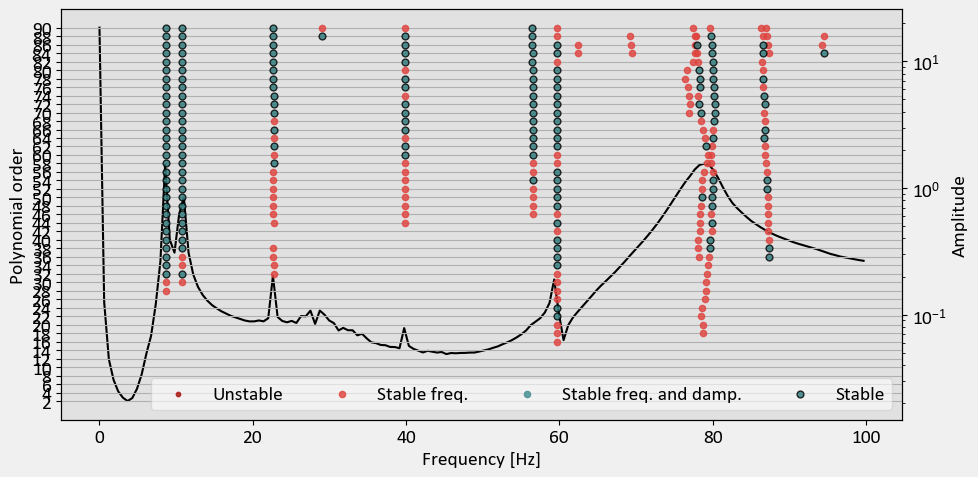

In [1524]:
# frf import
%matplotlib inline
point = 'EMA'  # 'Virtual EMA', 'EMA', 'joint_space'

if point == 'Y_rigid':
    Y_ = Y_rigid
    freq_ = freq
if point == 'Virtual EMA':
    Y_ = Y_virtual
    freq_ = freq_virtual
if point == 'EMA':
    Y_ = Y
    freq_ = freq
if point == 'joint_space':
    Y_ = Y_joint_space_from_cartesian
    freq_ = freq_virtual
fllim = np.where(freq_ >= 0)[0][0]
fhlim = np.where(freq_ >= 100)[0][0]

_id = modal_id.ModalID(freq_[fllim:fhlim], Y_[fllim:fhlim,:,:1])
_id.pLSCF(max_order=90)
_id.stabilization()

In [1526]:
_id.pLSFD(frf_type = 'accelerance', lower_residuals=False, upper_residuals = True, assume_proportional = 1)
if _id.assuming_proportional:
    Phi = _id.A[:,:,0].T
else:
    Phi = _id.R[:,:,0].T
# print('Avg. coh.: ', pyFBS.coh_frf(Y_virtual[fllim:fhlim], _id.FRF_rec).round(2))

f_r = _id.nat_freq
xi_r = _id.damp_ratio

In [1527]:
f_r

array([ 8.62096036, 10.75858363, 79.93834456])

In [159]:
q_full = [0,0,0,30,90]

In [1529]:
robot.plot()

In [160]:

robot.update(q=q_full)
stl = robot.plotter.add_meshes(return_stl=True)

df_sensors, df_channels = Antena_dynamics.get_global_acc_data(q_full)
view3D = pyfbs.display.View3D(show_origin=True)
mesh = view3D.add_stl(stl,name = 'robot', opacity = 0.3)

In [1531]:
pts = np.asarray(df_acc[['Position_1', 'Position_2', 'Position_3']])[:]



# cells = np.array([ 3,  0, 40,  3,  3,  3, 40, 41,  3, 40, 39,  0,  3,  2, 39,  0,  4,
#        40, 41, 38, 39,  3, 38, 39,  2,  3, 38,  1, 41,  3,  2, 38,  1,  3,
#         3, 41,  1,  4, 35, 33, 28,  6,  4,  6, 28,  7, 29,  4,  7, 29,  5,
#        31,  4, 32,  4, 30, 34,  4,  4, 30,  5, 31,  4, 13, 11, 10, 12,  4,
#        15, 11, 10, 14,  4, 12,  9,  8, 13,  4, 15,  8,  9, 14,  4, 12,  9,
#        14, 10,  4, 13,  8, 15, 11,  3, 20, 21, 36,  3, 18, 19, 37,  4, 21,
#        22, 23, 20,  4, 23, 22, 18, 19,  3, 16, 14, 15,  3, 14, 17, 15,  4,
#        25, 27, 26, 24,  4, 26, 22, 23, 24,  3, 26, 21, 22,  3, 26, 22, 18,
#         4, 24, 26, 21, 20,  3, 23, 24, 20,  3, 24, 23, 19,  4, 26, 24, 19,
#        18])
# cells = np.array([ 4, 22, 20, 21, 23,  4, 22, 14, 15, 20,  4, 20, 22, 17, 16,  4, 15,
#        19, 16, 20,  4, 17, 22, 14, 18,  6, 15, 14, 18, 17, 16, 19,  3, 16,
#        17, 32,  3, 14, 15, 33,  4,  4, 11,  7,  9,  4,  5, 10,  6,  8,  4,
#         8,  9,  7,  6,  4,  7, 11, 10,  6,  4,  4,  9,  8,  5,  4, 11, 10,
#         5,  4,  4,  0, 26,  1, 27,  4, 25,  3, 24,  2,  4,  2, 31, 29, 24,
#         4, 26,  0, 28, 30,  4, 35, 34, 30, 28,  4, 37, 31, 29, 36,  4,  3,
#        27,  1, 25]) # brez krožnika
# cells = np.array([1,1])
cells = np.array([ 4,  2, 24,  3, 25,  4,  0, 26,  1, 27,  4,  8,  6, 10,  5,  4,  4,
        9,  7, 11,  4,  9,  8,  5,  4,  4,  4,  5, 10, 11,  4,  6,  8,  9,
        7,  4, 10, 11,  7,  6,  3, 16, 28, 17,  4, 18, 19, 16, 17,  4, 18,
       19, 15, 14,  3, 14, 29, 15,  4, 15, 14, 22, 20,  4, 20, 22, 17, 16,
        4, 15, 19, 16, 20,  4, 17, 18, 14, 22,  4, 20, 21, 23, 22,  4, 27,
        5,  6,  1,  4,  7, 25,  3,  4]) # brez podpore krožnika

grid = pv.PolyData(pts)
grid_lines = pv.PolyData(pts, faces = cells)


view3D.plot.add_mesh(grid_lines, 
                     scalars = np.ones(pts.shape[0])+40,
                     cmap = "jet",
                     interpolate_before_map=True,
                     render_lines_as_tubes = True,
                     render_points_as_spheres = True,
                     line_width = 5,
                     point_size = 10,
                     name='grid_lines',
                     reset_camera = False,);

view3D.plot.add_mesh(grid,
                     scalars = df_acc['Description'],
                     cmap = "jet",
                     render_lines_as_tubes = True,
                     render_points_as_spheres = True,
                     line_width = 5,
                     point_size = 15,
                     name='grid1',
                     reset_camera = False,);

c:\Users\matic\Desktop\Yaskawa\Yaskawa-project-Repo\ROBO2_venv\Lib\site-packages\pyvista\core\utilities\points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


In [1532]:
view3D.plot.remove_scalar_bar()

In [1535]:
mode = 2
mshp = Phi
modeshape = -mshp[:,mode]
# modeshape = Phi_virtual[:,mode]
df_chn = pyfbs.utility.generate_channels_from_sensors(df_acc[:])
df_chn[['Direction_1', 'Direction_2', 'Direction_3']] = chn_dirs
_modeshape = pyfbs.utility.orient_in_global(modeshape, df_chn, df_acc[:])

view3D.take_gif = True
view = 1
view3D.gif_dir = 'temp/GIFS/Antena_EMA/EMA_exp_mshp_mode_'+str(mode)+f'_{view}'+'.mp4'

mode_dict = pyfbs.utility.dict_animation(_modeshape,"modeshape", pts = pts, mesh = [grid, grid_lines], r_scale = 100, no_of_repetitions = 1, no_points = 1*120, object_list=[grid, grid_lines],fps=60)
mode_dict["freq"] = f_r[mode]
mode_dict["damp"] = xi_r[mode]
mode_dict["mcf"] = pyfbs.utility.MCF(mshp[:,mode])*100
view3D.add_modeshape(mode_dict,run_animation = True, add_note=True)

c:\Users\matic\Desktop\Yaskawa\Yaskawa-project-Repo\ROBO2_venv\Lib\site-packages\pyvista\plotting\plotter.py:4892: PyVistaDeprecationWarning: This method is deprecated and will be removed in a future version of PyVista. Directly modify the points of a mesh in-place instead.
  warnings.warn(
c:\Users\matic\Desktop\Yaskawa\Yaskawa-project-Repo\ROBO2_venv\Lib\site-packages\pyvista\plotting\plotter.py:4814: PyVistaDeprecationWarning: This method is deprecated and will be removed in a future version of PyVista. Directly modify the scalars of a mesh in-place instead.
  warnings.warn(
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1058, 1784) to (1072, 1792) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [733]:
K_id = np.array([269836.15219335, 184760.33916284, 188100.85553095, 611501.93496914,
       593900.57651741])
Antena_dynamics.K = np.diag(K_id)

In [1547]:
f_r

array([ 8.62096036, 10.75858363, 79.93834456])

In [27]:
Antena.plot(origin=False)

c:\Users\matic\Desktop\DigitalTwin_Workshop\myvenv\Lib\site-packages\pyvista\core\utilities\misc.py:289: PyVistaDeprecationWarning: 
myvenv/Lib/site-packages/pyvista/core/utilities/misc.py:289: Arguments 'position', 'focal_point', 'color' must be passed as keyword arguments to function 'Light.__init__'.
From version 0.50, passing these as positional arguments will result in a TypeError.
  obj = super().__call__(*args, **kwargs)  # type: ignore[misc]


In [29]:
mode = 2

modeshape = Antena_dynamics.create_modeshape(q = [0,0,0,30,90],mode = mode, scale = 12, phase = -1)
stl = Antena.plotter.add_meshes(return_stl=True)
Antena.plotter.plot.add_mesh(stl, style='wireframe', color='black', name = 'stl', silhouette=True, opacity=0.3)
Antena.animate(modeshape, save_video =False,
            video_file=f'temp/GIFS/Antena_NUM/Antena_ext_num_mode_V2_{mode}.mp4',
            FPS=60)

Using cached eigenvalues and eigenvectors...
Generating meshes...


100%|██████████| 60/60 [00:06<00:00,  9.38it/s]


In [ ]:
traj = rb.Trajectory(Antena, q_0 = [0,0,0,0,0], q_f = [0,0,0,90,30], t_eval=np.linspace(0,2,300*5))

In [194]:
traj_sim = Antena_dynamics.simulate_trajectory(traj)

Last time: 2.00 s


In [195]:
traj.plot_cartesian()

In [196]:
%matplotlib qt
traj_sim.plot_cartesian()

In [ ]:
Antena.animate(traj)

100%|██████████| 150/150 [00:03<00:00, 44.32it/s]
